In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import pymorphy3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
df = pd.read_excel('social media.xlsx',header=None)
df.head()

,0
0,Voices from Team South Africa at BRICS 2025\nS...
1,Our CEO Mr Neville Matjie shared his thoughts ...
2,"His excellency President Cyril Ramaphosa, deli..."
3,President Cyril Ramaphosa has arrived in Rio d...
4,"Brand South Africa, in partnership with B20, B..."


In [25]:
df.columns = ['text']
df.head()

,text
0,Voices from Team South Africa at BRICS 2025\nS...
1,Our CEO Mr Neville Matjie shared his thoughts ...
2,"His excellency President Cyril Ramaphosa, deli..."
3,President Cyril Ramaphosa has arrived in Rio d...
4,"Brand South Africa, in partnership with B20, B..."


In [27]:
stop_words = stopwords.words('english') + stopwords.words('russian') 

In [29]:
morph = pymorphy3.MorphAnalyzer()

In [31]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [33]:
# применяем функцию к датафрейму с помощью метода .apply()
tokenized= df['text'].apply(tokenize_text)

In [35]:
# добавляем новую колонку в исходный датафрейм
df = df.assign(tokenized=tokenized)
df.head()

,text,tokenized
0,Voices from Team South Africa at BRICS 2025\nS...,"[voices, team, south, africa, brics, south, af..."
1,Our CEO Mr Neville Matjie shared his thoughts ...,"[ceo, neville, matjie, shared, thoughts, ongoi..."
2,"His excellency President Cyril Ramaphosa, deli...","[excellency, president, cyril, ramaphosa, deli..."
3,President Cyril Ramaphosa has arrived in Rio d...,"[president, cyril, ramaphosa, arrived, rio, ja..."
4,"Brand South Africa, in partnership with B20, B...","[brand, south, africa, partnership, bbcsa, cni..."


In [37]:
words_list_posts = list(df['tokenized'])

In [39]:
all_words_posts = np.concatenate(words_list_posts)

In [41]:
all_words_freq_posts = FreqDist(all_words_posts)
print("Наиболлее популярные слова: ", all_words_freq_posts.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words_freq_posts.keys()))

Наиболлее популярные слова:  [('brics', 158), ('south', 98), ('global', 79), ('africa', 62), ('summit', 56), ('president', 53), ('ramaphosa', 33), ('bricsza', 33), ('cyril', 30), ('development', 28), ('minister', 27), ('china', 26), ('world', 24), ('leaders', 23), ('international', 21), ('republic', 21), ('cooperation', 20), ('trade', 19), ('economic', 19), ('countries', 17), ('new', 17), ('state', 17), ('meeting', 16), ('business', 15), ('forum', 14), ('power', 13), ('role', 13), ('law', 13), ('members', 12), ('excellency', 12), ('hosted', 12), ('глобальный', 12), ('western', 12), ('shared', 11), ('security', 11), ('growth', 11), ('challenges', 11), ('sandton', 11), ('nations', 10), ('future', 10), ('брикс', 10), ('platform', 10), ('media', 10), ('inclusive', 10), ('centre', 10), ('investment', 9), ('support', 9), ('sustainable', 9), ('brazil', 9), ('one', 9), ('remarks', 9), ('across', 9), ('national', 9), ('russia', 9), ('india', 9), ('focus', 8), ('growing', 8), ('access', 8), ('ou

C:\Temp\ipykernel_13124\3957900171.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


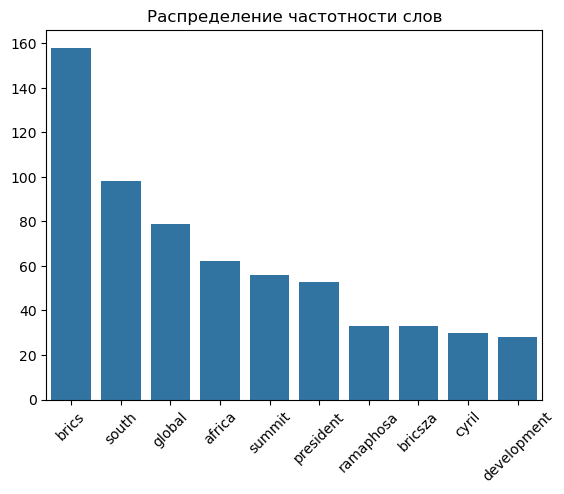

In [43]:
count, words = [], []
for w in all_words_freq_posts.most_common(10):
    words.append(w[0])
    count.append(w[1])

ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [47]:
df.to_csv('social_media_tokens.csv')

In [49]:
df = pd.read_csv('social_media_tokens.csv',index_col=0)
df.head()

,text,tokenized
0,Voices from Team South Africa at BRICS 2025\nS...,"['voices', 'team', 'south', 'africa', 'brics',..."
1,Our CEO Mr Neville Matjie shared his thoughts ...,"['ceo', 'neville', 'matjie', 'shared', 'though..."
2,"His excellency President Cyril Ramaphosa, deli...","['excellency', 'president', 'cyril', 'ramaphos..."
3,President Cyril Ramaphosa has arrived in Rio d...,"['president', 'cyril', 'ramaphosa', 'arrived',..."
4,"Brand South Africa, in partnership with B20, B...","['brand', 'south', 'africa', 'partnership', 'b..."


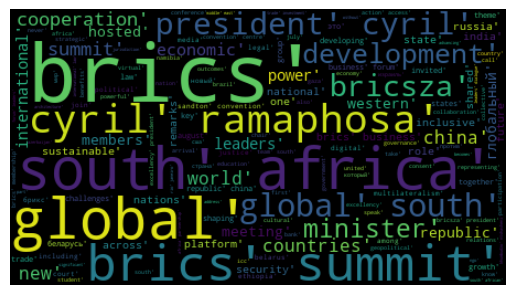

In [51]:
textt = ''.join(w for w in df.tokenized)
wordcloud = WordCloud(width=450,height=250).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [53]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(df.tokenized)

In [55]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['это', 'team', 'south', 'мир', 'power', 'который', 'страна', 'africa', 'глобальный', 'брикс']


Top 10 words for topic #1:
['leaders', 'cyril', 'ramaphosa', 'africa', 'bricsza', 'summit', 'global', 'president', 'south', 'brics']




In [57]:
topic_values = LDA.transform(doc_term_matrix)
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]

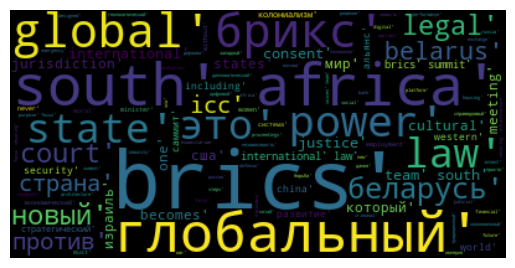

In [61]:
textt = ''.join(w for w in topic_1.tokenized)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

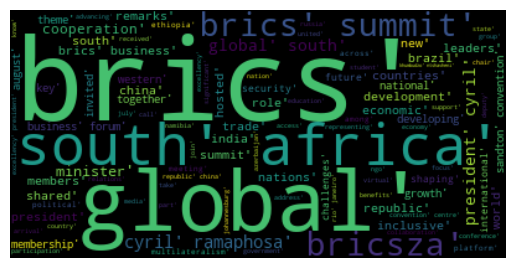

In [65]:
textt = ''.join(w for w in topic_2.tokenized)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [67]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['republic', 'partnership', 'ramaphosa', 'china', 'cooperation', 'south', 'brics', 'africa', 'summit', 'president']


Top 10 words for topic #1:
['extraordinary', 'world', 'countries', 'role', 'leaders', 'held', 'meeting', 'south', 'brics', 'global']


Top 10 words for topic #2:
['ramaphosa', 'cyril', 'sandton', 'forum', 'summit', 'africa', 'president', 'south', 'bricsza', 'brics']




In [69]:
topic_values = LDA.transform(doc_term_matrix)
df['Topic_LDA'] = topic_values.argmax(axis=1)
topic_1 = df[df['Topic_LDA']==0]
topic_2 = df[df['Topic_LDA']==1]
topic_3 = df[df['Topic_LDA']==2]

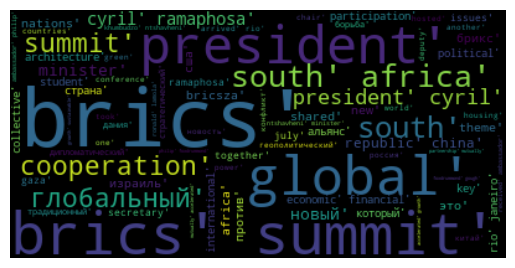

In [71]:
textt = ''.join(w for w in topic_1.tokenized)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

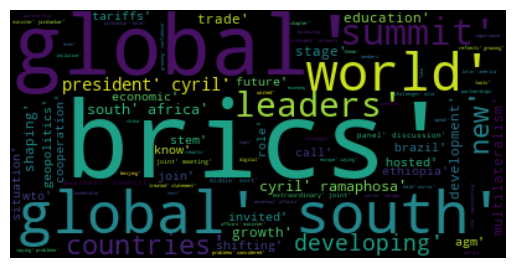

In [73]:
textt = ''.join(w for w in topic_2.tokenized)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

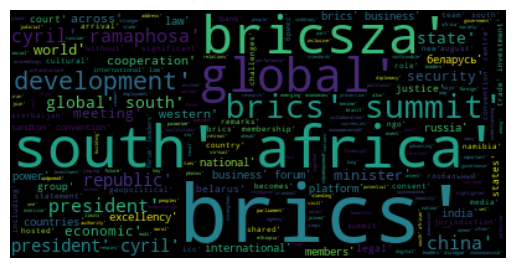

In [75]:
textt = ''.join(w for w in topic_3.tokenized)
wordcloud = WordCloud().generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()